# 1) Project Setup

This section defines imports, random seed, and file paths used throughout the notebook.

In [2]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproucibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Display settings
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

# Project paths
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data"
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"

print("Project root:", PROJECT_ROOT)
print("Data folder exists:", DATA_DIR.exists())
print("train.csv exists:", TRAIN_PATH.exists())
print("test.csv exists:", TEST_PATH.exists())

Project root: c:\Users\Xslayer77\Documents\kaggle_titanic
Data folder exists: True
train.csv exists: True
test.csv exists: True


# 2) Load Data

Purpose: Load training and test datasets into pandas DataFrames.

In this section I will:
- Read the CSV files for train and test data.
- Print dataset shapes to verify expected row counts.
- Preview first rows to confirm successful loading.

Expected outcome:
- Train and test DataFrames are available.
- Basic structure of each dataset is visible.

In [3]:
# Load data
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())
display(test_df.head())

Train shape: (891, 12)
Test shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


# 3) Data Quality Checks

Purpose: Understand data completeness and structure before modeling.

In this section I will:
- Check missing values by column.
- Inspect data types for each feature.
- Review target distribution for Survived.

Expected outcome:
- Clear list of columns needing cleaning or imputation.
- Awareness of class balance in the target.

In [4]:
# Data Quality Checks

# Missing values
missing_train = train_df.isnull().sum().sort_values(ascending=False)
missing_test = test_df.isnull().sum().sort_values(ascending=False)

print("Missing values in train (top 10):")
display(missing_train.head(10).to_frame("missing_count"))

print("Missing values in test (top 10):")
display(missing_test.head(10).to_frame("missing_count"))

# Data types
print("Train dtypes:")
display(train_df.dtypes.to_frame("dtype"))

print("Test dtypes:")
display(test_df.dtypes.to_frame("dtype"))

# Target distribution
target_counts = train_df["Survived"].value_counts().sort_index()
target_ratio = train_df["Survived"].value_counts(normalize=True).sort_index()

print("Target counts (0=Did not survive, 1=Survived):")
display(target_counts.to_frame("count"))

print("Target proportions:")
display((target_ratio * 100).round(2).to_frame("percent"))

Missing values in train (top 10):


,missing_count
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0


Missing values in test (top 10):


,missing_count
Cabin,327
Age,86
Fare,1
Name,0
Pclass,0
PassengerId,0
Sex,0
Parch,0
SibSp,0
Ticket,0


Train dtypes:


...

,dtype
PassengerId,int64
Pclass,int64
Name,str
Sex,str
Age,float64
SibSp,int64
Parch,int64
Ticket,str
Fare,float64
Cabin,str


Target counts (0=Did not survive, 1=Survived):


,count
Survived,
0,549
1,342


Target proportions:


,percent
Survived,
0,61.62
1,38.38


### Unique Values per Column

This check shows how many distinct values each column has (including missing values), which helps identify low-cardinality categorical features and high-cardinality fields like Name or Ticket.

In [5]:
# Unique values per column (including NaN)
unique_train = train_df.nunique(dropna=False).sort_values(ascending=False)
unique_test = test_df.nunique(dropna=False).sort_values(ascending=False)

print("Unique values in train:")
display(unique_train.to_frame("unique_count"))

print("Unique values in test:")
display(unique_test.to_frame("unique_count"))

Unique values in train:


,unique_count
PassengerId,891
Name,891
Ticket,681
Fare,248
Cabin,148
Age,89
SibSp,7
Parch,7
Embarked,4
Pclass,3


Unique values in test:


,unique_count
PassengerId,418
Name,418
Ticket,363
Fare,170
Age,80
Cabin,77
Parch,8
SibSp,7
Pclass,3
Embarked,3


## Observation
- **Cabin** has a large number of missing values.
- **Age** and **Embarked** require imputation
- **PassengerId**, **Name** and **Ticket** has too many unique values to be of use
- **Name** may be useful for feature extraction (e.g., titles)

# 4) EDA (Exploratory Data Analysis)

Purpose: Explore relationships between features and survival.

In this section I will:
- Create key visualizations such as survival by Sex and Pclass.
- Inspect Age and Fare distributions.
- Write short observations after each chart.

Expected outcome:
- Evidence-based hypotheses for feature engineering and model selection.

Survival rate by Sex:


,survival_percent
Sex,
female,74.20
male,18.89


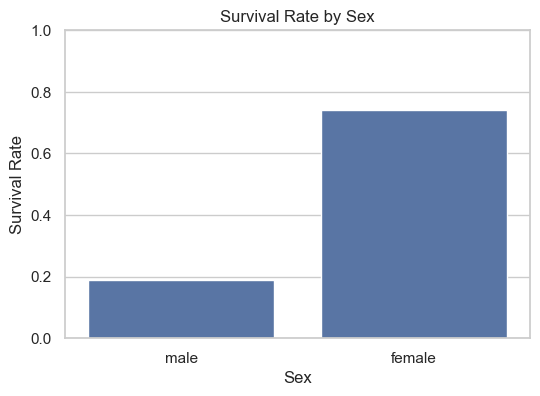

Survival rate by Pclass:


,survival_percent
Pclass,
1,62.96
2,47.28
3,24.24


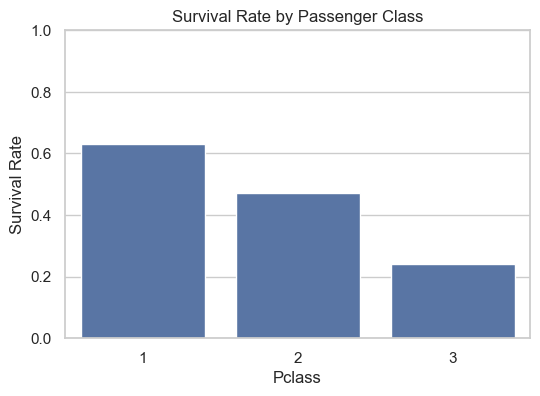

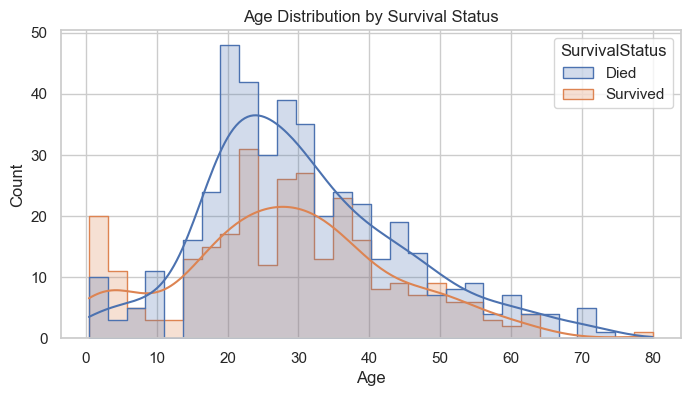

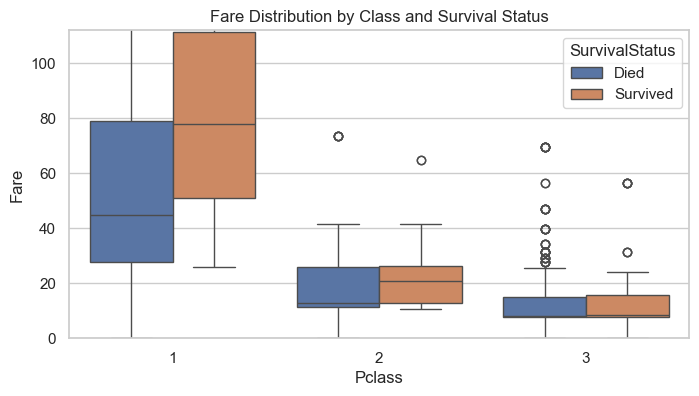

Survival rate by Embarked:


,survival_percent
Embarked,
C,55.36
Q,38.96
S,33.70


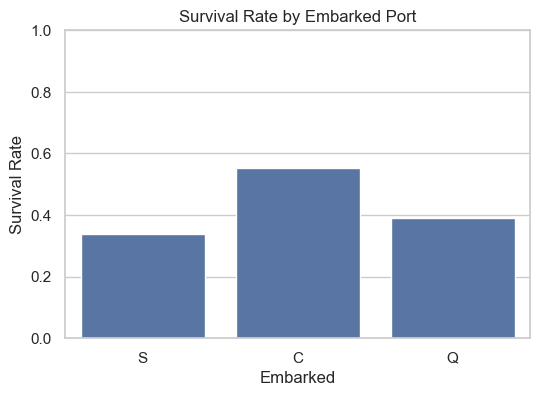

In [8]:
# EDA

# Safety copy
eda_df = train_df.copy()

# Human-readable survival labels for plots/legends
survival_label_map = {0: "Died", 1: "Survived"}
eda_df["SurvivalStatus"] = eda_df["Survived"].map(survival_label_map)

# 1) Survival by Sex
sex_survival = eda_df.groupby("Sex")["Survived"].mean().sort_values(ascending=False)
print("Survival rate by Sex:")
display((sex_survival * 100).round(2).to_frame("survival_percent"))

plt.figure(figsize=(6, 4))
sns.barplot(data=eda_df, x="Sex", y="Survived", estimator="mean", errorbar=None)
plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()

# 2) Survival by Pclass
pclass_survival = eda_df.groupby("Pclass")["Survived"].mean()
print("Survival rate by Pclass:")
display((pclass_survival * 100).round(2).to_frame("survival_percent"))

plt.figure(figsize=(6, 4))
sns.barplot(data=eda_df, x="Pclass", y="Survived", estimator="mean", errorbar=None)
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()

# 3) Age distribution by survival
plt.figure(figsize=(8, 4))
sns.histplot(
    data=eda_df,
    x="Age",
    hue="SurvivalStatus",
    hue_order=["Died", "Survived"],
    bins=30,
    kde=True,
    element="step"
)
plt.title("Age Distribution by Survival Status")
plt.show()

# 4) Fare distribution by class and survival
plt.figure(figsize=(8, 4))
sns.boxplot(
    data=eda_df,
    x="Pclass",
    y="Fare",
    hue="SurvivalStatus",
    hue_order=["Died", "Survived"]
)
plt.title("Fare Distribution by Class and Survival Status")
plt.ylim(0, eda_df["Fare"].quantile(0.95))  # reduce extreme outlier effect
plt.show()

# 5) Embarked vs survival
embarked_survival = eda_df.groupby("Embarked")["Survived"].mean()
print("Survival rate by Embarked:")
display((embarked_survival * 100).round(2).to_frame("survival_percent"))

plt.figure(figsize=(6, 4))
sns.barplot(data=eda_df, x="Embarked", y="Survived", estimator="mean", errorbar=None)
plt.title("Survival Rate by Embarked Port")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()

## Observation
- **Females** show much higher survival rate than males.
- **First-class passengers** survive more often than third-class passengers.
- **Age** and **Fare** appear to carry signal, but with overlap.
- **Embarkation port** may contain weaker but useful signal.


# 5) Feature Engineering

Purpose: Create more informative features from raw columns.

In this section I will:
- Build useful features such as FamilySize and IsAlone.
- Extract Title from passenger names.
- Optionally derive Deck from Cabin.

Expected outcome:
- Enhanced feature set ready for preprocessing and modeling.

In [11]:
# Feature Engineering

# Work on copies to avoid modifying original loaded data
train_fe = train_df.copy()
test_fe = test_df.copy()

def add_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # 1) Family size features
    out["FamilySize"] = out["SibSp"] + out["Parch"] + 1
    out["IsAlone"] = (out["FamilySize"] == 1).astype(int)

    # 2) Title from Name
    out["Title"] = out["Name"].str.extract(r",\\s*([^\\.]+)\\.", expand=False).str.strip()

    # Group rare titles to reduce noise
    common_titles = {"Mr", "Mrs", "Miss", "Master"}
    out["Title"] = out["Title"].where(out["Title"].isin(common_titles), "Rare")

    # 3) Deck from Cabin
    out["Deck"] = out["Cabin"].str[0]
    out["Deck"] = out["Deck"].fillna("Unknown")

    # 4) Ticket group size (shared ticket can indicate group travel)
    ticket_counts = out["Ticket"].value_counts()
    out["TicketGroupSize"] = out["Ticket"].map(ticket_counts)

    return out

train_fe = add_features(train_fe)
test_fe = add_features(test_fe)

print("New engineered columns added:")
new_cols = ["FamilySize", "IsAlone", "Title", "Deck", "TicketGroupSize"]
print(new_cols)

print("\nPreview of engineered features (train):")
display(train_fe[new_cols + ["Survived"]].head())

print("\nUnique values in Title (train):")
display(train_fe["Title"].value_counts().to_frame("count"))

print("\nUnique values in Deck (train):")
display(train_fe["Deck"].value_counts().to_frame("count"))

New engineered columns added:
['FamilySize', 'IsAlone', 'Title', 'Deck', 'TicketGroupSize']

Preview of engineered features (train):


,FamilySize,IsAlone,Title,Deck,TicketGroupSize,Survived
0,2,0,Rare,Unknown,1,0
1,2,0,Rare,C,1,1
2,1,1,Rare,Unknown,1,1
3,2,0,Rare,C,2,1
4,1,1,Rare,Unknown,1,0



Unique values in Title (train):


,count
Title,
Rare,891



Unique values in Deck (train):


,count
Deck,
Unknown,687
C,59
B,47
D,33
E,32
A,15
F,13
G,4
T,1


## Observation
- `FamilySize` and `IsAlone` capture household/travel-group context.
- `Title` contains no useful info as all passengers have a title.
- `Deck` has many `Unknown` values but can still carry location signal.
- `TicketGroupSize` doesn't seem to provide any useful signals either.

# 6) Preprocessing + Modeling

Purpose: Build a reliable machine learning pipeline.

In this section I will:
- Define numeric and categorical preprocessing steps.
- Combine preprocessing and model into one pipeline.
- Evaluate using Stratified K-Fold cross-validation.

Expected outcome:
- Baseline CV score with leakage-safe workflow.


In [ ]:
# Preprocessing + Modeling

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

TARGET_COL = "Survived"

# editable array of redundant colsumns
REDUNDANT_COLS = ["PassengerId", "Name", "Ticket", "Cabin", "Title", "TicketGroupSize"]

cols_to_drop_train = [c for c in REDUNDANT_COLS if c in train_fe.columns]
cols_to_drop_test = [c for c in REDUNDANT_COLS if c in test_fe.columns]

X = train_fe.drop(columns=[TARGET_COL] + cols_to_drop_train).copy()
y = train_fe[TARGET_COL].copy()
X_test_final = test_fe.drop(columns=cols_to_drop_test).copy()

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

baseline_model = LogisticRegression(max_iter=1000, random_state=SEED)

baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", baseline_model),
    ]
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results = cross_validate(
    baseline_pipeline,
    X,
    y,
    cv=cv,
    scoring="accuracy",
    return_train_score=False,
)

print("Dropped columns:", cols_to_drop_train)
print("Feature shape after drop:", X.shape)
print("Test feature shape after drop:", X_test_final.shape)
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print(
    f"Baseline CV Accuracy: {cv_results['test_score'].mean():.4f} +/- {cv_results['test_score'].std():.4f}"
)

Dropped columns: ['PassengerId', 'Name', 'Ticket', 'Cabin']
Feature shape after drop: (891, 12)
Test feature shape after drop: (418, 12)
Numeric features: 8
Categorical features: 4
Baseline CV Accuracy: 0.7991 +/- 0.0272
